In [1]:
import rawpy
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
os.chdir("../")

from datasets.dataset import RawJpegMaskLMDBDataset
from torch.utils.data import ConcatDataset, DataLoader
import tqdm
from collections import Counter
import torch
from configs.default import *


In [ ]:

data_name = [
    "Canon1DsMkIII",
    "Canon600D",
    # "NikonD40",
    # "NikonD5200",
    "OlympusEPL6",
    "PanasonicGX1",
    "SamsungNX2000",
    # "SonyA57",  # for weird 15 bit depth
    "raise",
]
data_paths = [os.path.join("./data", name) for name in data_name]

jpeg_mask_ratio = 0.0
patch_sz = 64
transform_val = RAWEvalTransform(patch_sz)
train_dataset = ConcatDataset(
    [
        RawJpegMaskLMDBDataset(data_path, split="train", transform=transform_val, jpeg_mask_ratio=jpeg_mask_ratio)
        for data_path in data_paths
    ]
)


dataloader = DataLoader(train_dataset, batch_size=64, num_workers=8, pin_memory=True, shuffle=False)

bit_counter = Counter()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for batch in tqdm.tqdm(dataloader):
        raw, jpeg = batch
        raw = raw.to(device, non_blocking=True, dtype=torch.int32)

        bit_depths = torch.ceil(
            torch.log2(torch.max(raw.view(raw.size(0), raw.size(1), -1), dim=-1).values.clip(min=0) + 1)
        )
        bit_depths = bit_depths.cpu().numpy()

        bit_counter.update(bit_depths.flatten().astype(int))
print(f"Patch size: {patch_sz}")
print("Bit-depth count =", bit_counter)


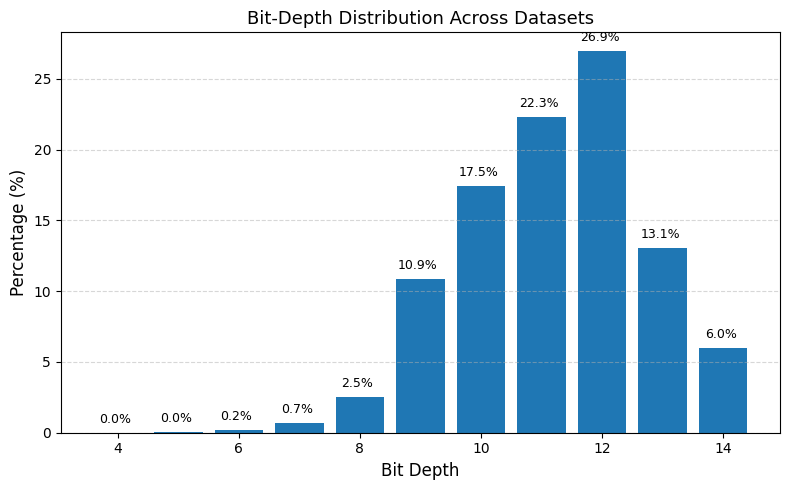

In [3]:
# plot bit depth
bit_depths = sorted(bit_counter.keys())
counts = np.array([bit_counter[b] for b in bit_depths])
percent = counts / counts.sum() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(bit_depths, percent)

# annotate %
for bar, p in zip(bars, percent):
    plt.text(
        bar.get_x() + bar.get_width()*0.45, 
        bar.get_height() + 0.5,
        f"{p:.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.title("Bit-Depth Distribution Across Datasets", fontsize=13)
plt.xlabel("Bit Depth", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:

def bayer2rgb(raw):
    """Convert RGGB raw image to RGB format."""
    height, width = raw.shape
    rgb_image = np.zeros((height // 2, width // 2, 3), dtype=raw.dtype)

    # Red channel
    rgb_image[:, :, 0] = raw[0:height:2, 0:width:2]
    # Green channel
    rgb_image[:, :, 1] = (raw[0:height:2, 1:width:2] + raw[1:height:2, 0:width:2]) / 2
    # Blue channel
    rgb_image[:, :, 2] = raw[1:height:2, 1:width:2]

    return rgb_image

def norm_by_bit_depth(x: torch.Tensor):
    bit_depths = torch.ceil(torch.log2(torch.max(x, dim=-1)[0] + 1))

    x_norm = x / (2**bit_depths.unsqueeze(-1) - 1)

    return x_norm, bit_depths


raw = rawpy.imread('example/NikonD5200_0076.NEF')
raw_image = raw.raw_image

raw_rgb = bayer2rgb(raw_image) 
raw_image_rotated = np.rot90(raw_rgb, k=3).copy()
raw_image_rotated = torch.from_numpy(raw_image_rotated).to(torch.int32)
x_norm, bit_depths = norm_by_bit_depth(raw_image_rotated)

In [5]:
torch.unique(bit_depths)

tensor([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.])

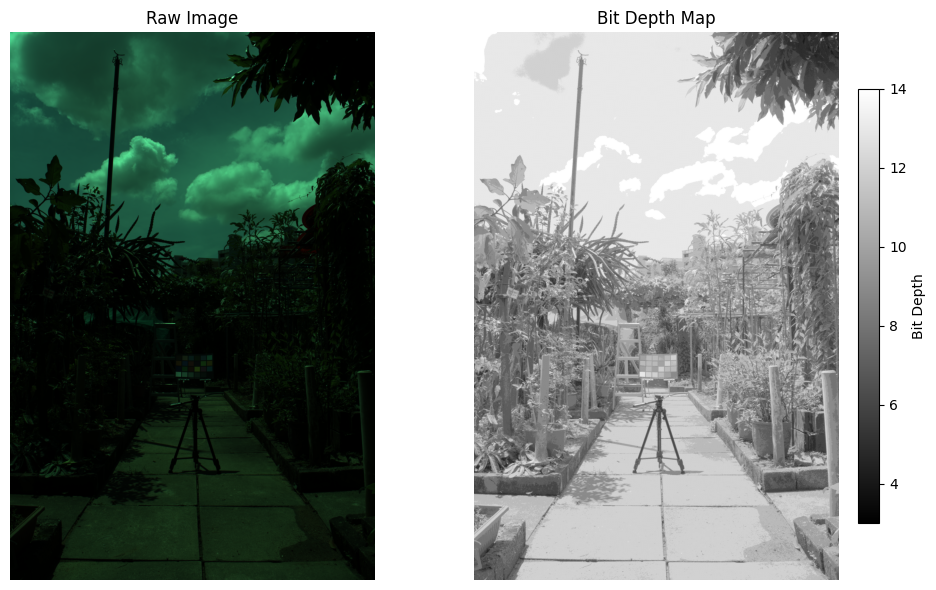

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


x_norm_np = raw_image_rotated / raw_image_rotated.max()
bit_depths_np = bit_depths.detach().cpu().numpy()


plt.figure(figsize=(10, 6))


ax1 = plt.subplot(1, 2, 1)
ax1.imshow(x_norm_np)  
ax1.set_title("Raw Image")
ax1.axis("off")


ax2 = plt.subplot(1, 2, 2)
img2 = ax2.imshow(bit_depths_np, cmap="gray")  
ax2.set_title("Bit Depth Map")
ax2.axis("off")


cbar = plt.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Bit Depth")

plt.tight_layout()
# plt.show()

# save as pdf
plt.savefig("tmp/bit_depth_visualization.pdf")


In [8]:

def bayer2rgb(raw):
    """Convert RGGB raw image to RGB format."""
    height, width = raw.shape
    rgb_image = np.zeros((height // 2, width // 2, 3), dtype=raw.dtype)

    # Red channel
    rgb_image[:, :, 0] = raw[0:height:2, 0:width:2]
    # Green channel
    rgb_image[:, :, 1] = (raw[0:height:2, 1:width:2] + raw[1:height:2, 0:width:2]) / 2
    # Blue channel
    rgb_image[:, :, 2] = raw[1:height:2, 1:width:2]

    return rgb_image

def norm_by_bit_depth(x: torch.Tensor):
    x= x.unsqueeze(-1)

    bit_depths = torch.ceil(torch.log2(torch.max(x, dim=-1)[0] + 1))

    x_norm = x / (2**bit_depths.unsqueeze(-1) - 1)

    return x_norm, bit_depths


raw = rawpy.imread('example/NikonD5200_0076.NEF')
raw_image = raw.raw_image


raw_image_rotated = np.rot90(raw_image, k=3).copy()
raw_image_rotated = torch.from_numpy(raw_image_rotated).to(torch.int32)
x_norm, bit_depths = norm_by_bit_depth(raw_image_rotated)

In [9]:
bit_depths.shape

torch.Size([6036, 4020])

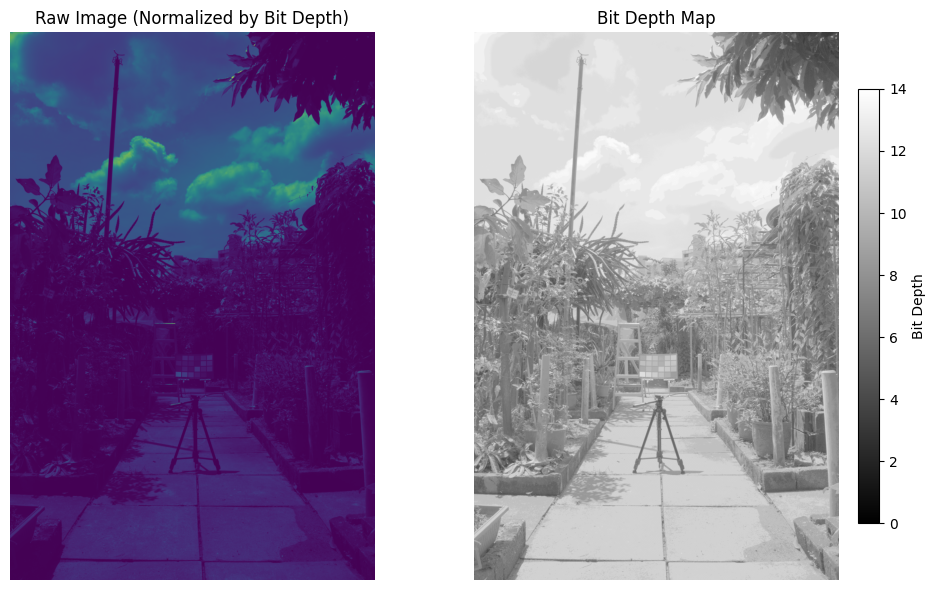

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


x_norm_np = raw_image_rotated / raw_image_rotated.max()
bit_depths_np = bit_depths.detach().cpu().numpy()


plt.figure(figsize=(10, 6))


ax1 = plt.subplot(1, 2, 1)
ax1.imshow(x_norm_np)   
ax1.set_title("Raw Image (Normalized by Bit Depth)")
ax1.axis("off")


ax2 = plt.subplot(1, 2, 2)
img2 = ax2.imshow(bit_depths_np, cmap="gray")  
ax2.set_title("Bit Depth Map")
ax2.axis("off")


cbar = plt.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Bit Depth")

plt.tight_layout()
plt.show()
